<a href="https://colab.research.google.com/github/larissajelima/churn-prediction-marketing-campaign/blob/main/churn_prediction_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Predição de Churn para Campanha de Marketing

## 🎯 Objetivo
Prever quais clientes têm maior probabilidade de aceitar uma oferta,
para otimizar campanhas e maximizar lucro.

## 💰 Estratégia de Negócio
Nem sempre o modelo com maior acurácia gera mais lucro.

Neste projeto, a decisão será baseada em:
- valor da venda
- custo da campanha
- erros do modelo

O foco é encontrar a estratégia mais lucrativa, não a mais precisa.

# 1. Carregamento dos dados

In [182]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset


In [183]:
import pandas as pd

df = pd.read_csv('/kaggle/input/bank-marketing-dataset/bank.csv')


# 2. Exploração inicial dos dados
## Aqui verificamos as primeiras linhas e os tipos de dados para entender a estrutura da base.

In [184]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


# 2. Limpeza e preparação dos dados
## Após verificar se Dtype mostrado na info está conforme esperado, verificamos nulos e mapeamos target

In [186]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [187]:
df['deposit'] = df['deposit'].map({'yes':1, 'no':0})

# 3. Criação de X e y
## Aqui criamos nossas variáveis, transformando categóricas, removendo colunas como duration(leakeage)

In [188]:
X = df.drop(['deposit', 'duration'], axis=1)

In [189]:
X = pd.get_dummies(X)

In [190]:
y = df['deposit']

In [191]:
X.shape

(11162, 50)

# 4. Treinamento do modelo
## 🧠 Estratégia de Modelagem

Será utilizado um modelo de árvore de decisão,
por ser simples e interpretável.

Também será testada uma versão com `class_weight='balanced'`
para aumentar a capacidade de identificar clientes que aceitariam a oferta.

##Modelo Base

In [192]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [193]:
from sklearn.tree import DecisionTreeClassifier

modelo_base = DecisionTreeClassifier(max_depth=5, random_state=42)

In [194]:
modelo_base.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [195]:
pred_base = modelo_base.predict(X_teste)

In [196]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_teste, pred_base))
print(classification_report(y_teste, pred_base))

[[1474  268]
 [ 775  832]]
              precision    recall  f1-score   support

           0       0.66      0.85      0.74      1742
           1       0.76      0.52      0.61      1607

    accuracy                           0.69      3349
   macro avg       0.71      0.68      0.68      3349
weighted avg       0.70      0.69      0.68      3349



## Modelo Balanceado

In [197]:
modelo_balanced = DecisionTreeClassifier(max_depth=5, class_weight='balanced')

In [198]:
modelo_balanced.fit(X_treino, y_treino)

DecisionTreeClassifier(class_weight='balanced', max_depth=5)

In [199]:
pred_balanced = modelo_balanced.predict(X_teste)

In [200]:
print(confusion_matrix(y_teste, pred_balanced))
print(classification_report(y_teste, pred_balanced))

[[1373  369]
 [ 679  928]]
              precision    recall  f1-score   support

           0       0.67      0.79      0.72      1742
           1       0.72      0.58      0.64      1607

    accuracy                           0.69      3349
   macro avg       0.69      0.68      0.68      3349
weighted avg       0.69      0.69      0.68      3349




## 💰 Otimização de Lucro

Aqui testamos diferentes thresholds para entender
qual estratégia gera maior retorno financeiro.

A ideia é encontrar o equilíbrio entre:
- capturar clientes (recall)
- custo da campanha (falsos positivos)

# 5. Otimização com threshold e lucro

In [201]:
probs = modelo_base.predict_proba(X_teste)[:,1]

In [205]:
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.1)

lucros = []

for t in thresholds:
    pred = (probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_teste, pred).ravel()

    lucro = (tp * 1000) - ((tp + fp) * 50)

    lucros.append(lucro)

    print(f"Threshold {t:.1f} → Lucro: {lucro}")

Threshold 0.1 → Lucro: 1437750
Threshold 0.2 → Lucro: 1378100
Threshold 0.3 → Lucro: 1315950
Threshold 0.4 → Lucro: 864100
Threshold 0.5 → Lucro: 777000
Threshold 0.6 → Lucro: 776450
Threshold 0.7 → Lucro: 347000
Threshold 0.8 → Lucro: 347000
347000


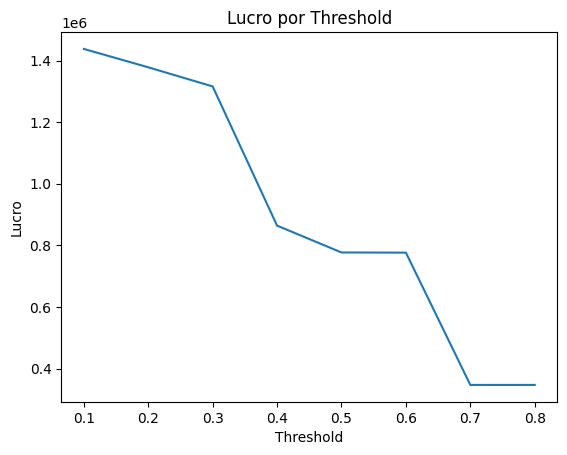

In [206]:
import matplotlib.pyplot as plt

plt.plot(thresholds, lucros)
plt.xlabel('Threshold')
plt.ylabel('Lucro')
plt.title('Lucro por Threshold')
plt.show()

# 📊 Resultado Final
O threshold 0.1 gerou maior lucro,
indicando que uma estratégia agressiva é mais vantajosa,
pois o valor da venda supera o custo da campanha.

## 🧠 Conclusão

O modelo inicial apresentou desempenho equilibrado,
mas deixou de capturar muitos clientes potenciais.

Ao reduzir o threshold, foi possível aumentar o recall,
capturando mais clientes que aceitariam a oferta.

Mesmo com aumento no custo da campanha,
a estratégia mais agressiva gerou maior lucro.

Isso demonstra que decisões baseadas em negócio
são mais relevantes do que métricas como acurácia.